# Four diagnostics behind the 27.07 findings

Each of these was first computed ad hoc while working through a question, and each ended up carrying a
claim in the progress report. This notebook exists so none of them is an unreproducible assertion.
No model is trained here — all four are properties of the **data** and of the **objective**, not of a
fitted model.

| § | Question it answers | Where the claim appears |
|---|---|---|
| 1 | Why was `nutlin-3` rejected by the learnability gate, and how many drugs share its fate? | report §1, slide 4 |
| 2 | How unevenly does the per-cell loss weight the cell lines? | report §5, slide 16 |
| 3 | Is the cell-line effect explained by proliferation, or by any annotated program? | report §6, slide 15 |
| 4 | Do the two representations enter the network on comparable scales? | report §10, slide 14 |

Sections 1–3 are settled findings. Section 4 is a **confound found late and not yet tested** — it is
here so the claim is checkable, not because it is resolved.

In [1]:
import sys
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from scripts.layout import PipelinePaths
from scripts.training.density_weighting import line_level

OUT = ROOT / 'notebooks' / 'outputs' / 'diagnostics'
OUT.mkdir(parents=True, exist_ok=True)

ACCENT, CONTEXT, INK, MUTED = '#2a78d6', '#c9c9c4', '#0b0b0b', '#52514e'
plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': MUTED, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.titlesize': 9,
    'axes.labelsize': 8, 'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'grid.color': '#e8e8e4', 'grid.linewidth': 0.6, 'font.size': 8,
})

a = ad.read_h5ad(PipelinePaths.build(None, 'hvg5000', 'auc').targets_h5ad, backed='r')
Y = np.asarray(a.obsm['Y_ctrp'], dtype=float)
M = np.asarray(a.obsm['M_ctrp'], dtype=bool)
drugs = list(a.uns['ctrp_drugs'])
groups = a.obs['Cell_line'].astype(str).to_numpy()
lines = np.unique(groups)

A, obsL = line_level(Y, M, groups, lines)   # (cell line x drug) raw auc + observation mask
A = pd.DataFrame(np.where(obsL, A, np.nan), index=lines, columns=drugs)
print(f'{A.shape[0]} cell lines x {A.shape[1]} drugs | labelled lines: {int(A.notna().any(axis=1).sum())}')

198 cell lines x 545 drugs | labelled lines: 180


## 1. The learnability gate filtered on potency, not on rankability

The gate required a drug to **kill** (`auc <= 0.5`) and **spare** (`auc >= 0.8`) a real population. But
the target subtracts the per-drug mean and the metric is Spearman, which reads only the *ordering* of
cell lines. Whether a drug's values sit around 0.4 or around 0.9 is invisible to both. So the gate
selected on a property the model is neither given nor scored on.

`nutlin-3` is the clean demonstration: same spread as `dasatinib`, zero kills, rejected. The reason is
pharmacological rather than technical — it is **cytostatic**, so p53 activation arrests growth without
killing, and viability never crosses 50 % however sensitive the line is. Any "does it kill" threshold
is structurally blind to every cytostatic agent.

In [2]:
KILL, SPARE, COV_MIN, STD_MIN = 0.5, 0.8, 0.90, 0.10
n_lines_total = int(A.notna().any(axis=1).sum())

gate = pd.DataFrame({
    'n_lines': A.notna().sum(axis=0),
    'auc_mean': A.mean(axis=0),
    'auc_std': A.std(axis=0, ddof=0),
    'kills': (A <= KILL).sum(axis=0),
    'spares': (A >= SPARE).sum(axis=0),
})
gate['cov_frac'] = gate['n_lines'] / n_lines_total

print('the comparison that exposed it:')
print(gate.loc[['dasatinib', 'nutlin-3'], ['auc_mean', 'auc_std', 'kills', 'spares']].round(3).to_string())

discarded = gate[(gate.kills == 0) & (gate.auc_std >= STD_MIN) & (gate.cov_frac >= COV_MIN)]
print(f'\ndrugs with ZERO kills but auc_std >= {STD_MIN} and coverage >= {COV_MIN:.0%}: '
      f'{len(discarded)} of {len(gate)}')
print('   widest of them:', ', '.join(discarded.sort_values('auc_std', ascending=False)
                                      .head(6).index.tolist()))
gate.round(3).to_csv(OUT / 'gate_per_drug.csv')

the comparison that exposed it:
           auc_mean  auc_std  kills  spares
dasatinib     0.631    0.155     35      27
nutlin-3      0.874    0.147      0     144

drugs with ZERO kills but auc_std >= 0.1 and coverage >= 90%: 116 of 545
   widest of them: fqi-2, ciclopirox, brd-k71781559, aa-cocf3, brd-k92856060, tacrolimus


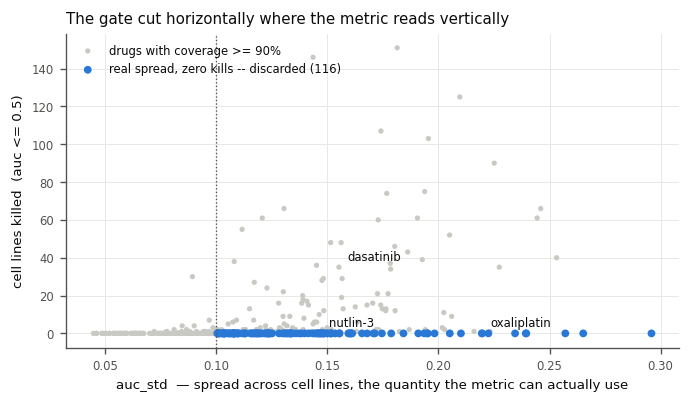

In [3]:
fig, ax = plt.subplots(figsize=(6.6, 3.4))
keep = gate.cov_frac >= COV_MIN
ax.scatter(gate.loc[keep, 'auc_std'], gate.loc[keep, 'kills'], s=10, color=CONTEXT,
           edgecolors='none', label=f'drugs with coverage >= {COV_MIN:.0%}')
ax.scatter(discarded['auc_std'], discarded['kills'], s=22, color=ACCENT, edgecolors='none',
           label=f'real spread, zero kills -- discarded ({len(discarded)})')
for d in ['nutlin-3', 'dasatinib', 'oxaliplatin']:
    if d in gate.index:
        ax.annotate(d, (gate.loc[d, 'auc_std'], gate.loc[d, 'kills']),
                    textcoords='offset points', xytext=(5, 4), fontsize=7, color=INK)
ax.axvline(STD_MIN, color=MUTED, linewidth=0.8, linestyle=':')
ax.set_xlabel('auc_std  — spread across cell lines, the quantity the metric can actually use')
ax.set_ylabel('cell lines killed  (auc <= 0.5)')
ax.set_title('The gate cut horizontally where the metric reads vertically', loc='left', color=INK)
ax.grid(True)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=7, loc='upper left')
fig.savefig(OUT / 'gate_potency_vs_spread.png')
plt.show()

## 2. The per-cell loss weights cell lines by how many cells were sequenced

The masked loss is a mean over observed **cells** (`training_utils.py`), but the label is one value per
**cell line**. A line therefore contributes in proportion to `cells x observed drugs`. The drug count is
legitimate information — a line screened on more compounds does say more. The cell count is not: it is
an artifact of the assay, and the label is identical across all of a line's cells.

This matters because the effective sample size is ~150 independent cell lines, not 53k cells.

In [4]:
cells = pd.Series(groups).value_counts()
labelled = A.notna().any(axis=1)
w = pd.DataFrame({'cells': cells.reindex(A.index), 'drugs': A.notna().sum(axis=1)})[labelled]
w['loss_share'] = (w.cells * w.drugs) / (w.cells * w.drugs).sum()
w = w.sort_values('loss_share', ascending=False)
fair = 1 / len(w)

print(f'{len(w)} labelled cell lines')
print(f'  cells per line : {w.cells.min()} .. {w.cells.max()}  (median {int(w.cells.median())}) '
      f'-> {w.cells.max() / w.cells.min():.0f}x')
print(f'  drugs per line : {w.drugs.min()} .. {w.drugs.max()}  (median {int(w.drugs.median())}) '
      f'-> {w.drugs.max() / w.drugs.min():.0f}x')
print(f'  loss share     : {w.loss_share.iloc[0]:.2%} ({w.index[0]}) down to '
      f'{w.loss_share.iloc[-1]:.3%} ({w.index[-1]}) -> {w.loss_share.iloc[0] / w.loss_share.iloc[-1]:.0f}x')
print(f'  equal shares would be {fair:.2%} each; the top 10 lines carry '
      f'{w.loss_share.head(10).sum():.1%} instead of {10 * fair:.1%}')
w.round(6).to_csv(OUT / 'loss_share_per_line.csv')

180 labelled cell lines
  cells per line : 56 .. 1990  (median 226) -> 36x
  drugs per line : 38 .. 505  (median 465) -> 13x
  loss share     : 4.37% (NCIH2110_LUNG) down to 0.054% (PANC1_PANCREAS) -> 82x
  equal shares would be 0.56% each; the top 10 lines carry 18.3% instead of 5.6%


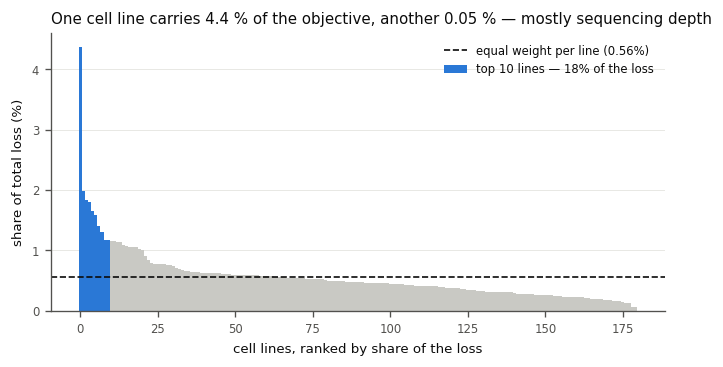

In [5]:
fig, ax = plt.subplots(figsize=(6.6, 3.0))
x = np.arange(len(w))
ax.bar(x, w.loss_share.values * 100, width=1.0, color=CONTEXT, edgecolor='none')
top = 10
ax.bar(x[:top], w.loss_share.values[:top] * 100, width=1.0, color=ACCENT, edgecolor='none',
       label=f'top {top} lines — {w.loss_share.head(top).sum():.0%} of the loss')
ax.axhline(fair * 100, color=INK, linewidth=1.0, linestyle='--',
           label=f'equal weight per line ({fair:.2%})')
ax.set_xlabel('cell lines, ranked by share of the loss')
ax.set_ylabel('share of total loss (%)')
ax.set_title('One cell line carries 4.4 % of the objective, another 0.05 % — mostly sequencing depth',
             loc='left', color=INK)
ax.grid(axis='y')
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=7)
fig.savefig(OUT / 'loss_share_per_line.png')
plt.show()

## 3. The cell-line effect is not proliferation — and no annotated program explains it

**Hypothesis.** A 72 h viability assay confounds drug effect with division rate: a faster-dividing line
loses more viability for the same drug effect. That is the motivation for GR metrics (Hafner et al.,
*Nat Methods* 2016; in `references.bib`). Proliferation is also the most visible axis in scRNA-seq. If
the cell-line effect were largely proliferation, it would explain both why ridge on line means ties the
MLP and why removing the cell-line effect costs a fifth of the signal.

**Why this test is clean.** SCP542 ships the authors' own published per-cell program scores, including
cell cycle (`G1/S_score`, `G2/M_score`) and the recurrent heterogeneity programs. No scoring choice of
ours enters.

**Cell-line effect** = the line's mean response over all drugs, in per-drug z units — DrEval's
definition. Negative = sensitive to everything.

Two controls decide whether the test could have found anything at all: the effect must have real spread,
and the program scores must vary *between* lines and not only within them (Kinker's programs were
designed to capture within-line heterogeneity, so this is not guaranteed).

In [6]:
Z = (A - A.mean(axis=0)) / A.std(axis=0, ddof=0)   # per-drug z across lines
line_effect = Z.mean(axis=1, skipna=True).dropna()

PROGRAMS = ['G1/S_score', 'G2/M_score', 'EMTI_score', 'EMTII_score', 'EMTIII_score', 'IFNResp_score',
            'p53Sen_score', 'EpiSen_score', 'StressResp_score', 'ProtMatu_score', 'ProtDegra_score',
            'SkinPig_score']
prog = pd.DataFrame({c: pd.to_numeric(a.obs[c].values, errors='coerce') for c in PROGRAMS})
prog['line'] = groups
per_line = prog.groupby('line').mean(numeric_only=True)
per_line['proliferation'] = per_line[['G1/S_score', 'G2/M_score']].mean(axis=1)

print('--- control 1: does the cell-line effect have real spread? ---')
print(f'   mean {line_effect.mean():+.3f}  std {line_effect.std():.3f}  '
      f'range {line_effect.min():+.2f} .. {line_effect.max():+.2f}   (z units)')
print('--- control 2: do the scores vary between lines, not just within? ---')
for c in ['G1/S_score', 'G2/M_score']:
    s = pd.Series(prog[c].values, index=groups)
    b, wi = s.groupby(level=0).mean().std(), s.groupby(level=0).std().mean()
    print(f'   {c:12s} between-line std {b:.3f} vs mean within-line std {wi:.3f}  (ratio {b / wi:.2f})')

rows = []
for c in PROGRAMS + ['proliferation']:
    j = per_line[c].reindex(line_effect.index)
    ok = j.notna()
    r, p = spearmanr(j[ok], line_effect[ok])
    rows.append({'program': c, 'rho': r, 'p': p, 'n': int(ok.sum())})
res = pd.DataFrame(rows).sort_values('rho', key=abs, ascending=False).set_index('program')
res.to_csv(OUT / 'line_effect_vs_programs.csv')
print(f'\nSpearman vs the cell-line effect (n = {res["n"].iloc[0]} lines):')
print(res.round(3).to_string())

--- control 1: does the cell-line effect have real spread? ---
   mean -0.010  std 0.398  range -2.10 .. +1.41   (z units)
--- control 2: do the scores vary between lines, not just within? ---


   G1/S_score   between-line std 0.233 vs mean within-line std 0.593  (ratio 0.39)
   G2/M_score   between-line std 0.254 vs mean within-line std 0.803  (ratio 0.32)

Spearman vs the cell-line effect (n = 180 lines):
                    rho      p    n
program                            
ProtDegra_score  -0.113  0.132  180
ProtMatu_score   -0.105  0.162  180
p53Sen_score      0.074  0.326  180
G1/S_score       -0.056  0.459  180
proliferation    -0.050  0.502  180
G2/M_score       -0.049  0.516  180
EMTI_score        0.049  0.517  180
SkinPig_score    -0.037  0.624  180
IFNResp_score    -0.030  0.691  180
EpiSen_score      0.025  0.734  180
EMTII_score       0.022  0.768  180
EMTIII_score      0.022  0.768  180
StressResp_score  0.013  0.860  180


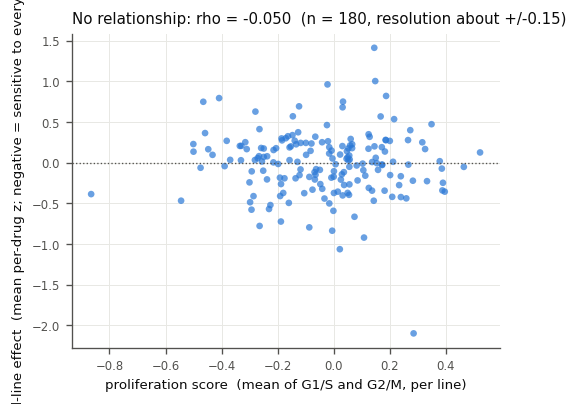

The effect is large and real, and none of the twelve published programs of this dataset
explains it. Removing it therefore discards no biology we would want to keep.


In [7]:
j = per_line['proliferation'].reindex(line_effect.index)
r = res.loc['proliferation', 'rho']
ci = 1.96 / np.sqrt(len(line_effect) - 3)   # Fisher-z half-width, ~the resolution of this test

fig, ax = plt.subplots(figsize=(4.6, 3.4))
ax.scatter(j, line_effect, s=16, color=ACCENT, edgecolors='none', alpha=0.7)
ax.axhline(0, color=MUTED, linewidth=0.8, linestyle=':')
ax.set_xlabel('proliferation score  (mean of G1/S and G2/M, per line)')
ax.set_ylabel('cell-line effect  (mean per-drug z; negative = sensitive to everything)')
ax.set_title(f'No relationship: rho = {r:+.3f}  (n = {len(line_effect)}, resolution about +/-{ci:.2f})',
             loc='left', color=INK)
ax.grid(True)
ax.set_axisbelow(True)
fig.savefig(OUT / 'line_effect_vs_proliferation.png')
plt.show()
print('The effect is large and real, and none of the twelve published programs of this dataset')
print('explains it. Removing it therefore discards no biology we would want to keep.')

## 4. The two representations enter the network on very different scales

**Open confound, not a finding.** Both models share one learning rate, one weight decay and one input
dropout. If the two inputs differ greatly in magnitude, the PCA model is effectively trained with a
different step size than the scGPT model, and every PCA-vs-scGPT comparison this project has made
carries that asymmetry.

The observable it would explain: PCA reaches its best validation epoch after **one** epoch in four of
five folds, while scGPT keeps improving for ten to twenty (`notebooks/14`). Which would mean the
epoch-1 behaviour says something about the configuration rather than about the information content —
and "PCA has no nonlinear structure to offer" would be weaker than it currently reads.

Note what the numbers below do and do not show: the *within*-representation conditioning is comparable,
so this is about absolute magnitude, not about ill-conditioned PCA components.

**Untested.** The decisive experiment is to standardize both inputs per dimension (fitted per fold on
training cells) and re-run. Either PCA then trains for many epochs and improves — in which case a
load-bearing conclusion needs revising — or it does not, and the conclusion is safer than it is today.

In [8]:
rows = []
for rep in ['X_pca', 'X_scGPT']:
    X = np.asarray(a.obsm[rep], dtype=np.float64)
    sd = X.std(axis=0)
    rows.append({'rep': rep, 'dims': X.shape[1], 'std_median': np.median(sd),
                 'std_max': sd.max(), 'std_min': sd.min(),
                 'within_rep_ratio': sd.max() / sd.min(), 'abs_mean_magnitude': np.abs(X).mean()})
scale = pd.DataFrame(rows).set_index('rep')
scale.to_csv(OUT / 'input_scale.csv')
print(scale.round(4).to_string())
print(f'\nbetween-representation ratio of median per-dimension std: '
      f'{scale.loc["X_pca", "std_median"] / scale.loc["X_scGPT", "std_median"]:.0f}x')
print('within-representation conditioning is comparable '
      f'({scale.loc["X_pca", "within_rep_ratio"]:.0f}x vs '
      f'{scale.loc["X_scGPT", "within_rep_ratio"]:.0f}x) -- the asymmetry is absolute magnitude')

         dims  std_median  std_max  std_min  within_rep_ratio  abs_mean_magnitude
rep                                                                              
X_pca     512      0.8152   7.7562   0.6983           11.1076              0.8131
X_scGPT   512      0.0104   0.0263   0.0045            5.8062              0.0245

between-representation ratio of median per-dimension std: 78x
within-representation conditioning is comparable (11x vs 6x) -- the asymmetry is absolute magnitude


## 5. How much do the results move? Two dispersions, and they answer different questions

The step-1 results were reported as a single number per configuration, which is not enough for a claim
of the form "scGPT beats PCA". Both dispersions below are computed from the **stored out-of-fold
predictions** — no retraining — and they are not interchangeable:

- **Across folds.** Recompute the score separately within each fold's held-out lines. This says how much
  the result depends on *which lines were held out*. It is the error bar an audience expects from a
  cross-validated number.
- **Across drugs.** The spread of the eight per-drug correlations around their mean. This says how
  unevenly the model performs *across compounds*, which for a per-drug metric is at least as
  informative.

One caveat worth stating rather than hiding: the fold-wise mean is a **different estimator** from the
pooled one. Pooling gives one correlation over ~150 lines; the fold-wise version averages five
correlations over ~30 lines each, which is noisier and sits slightly higher. Report the pooled value as
the point estimate and the fold spread as the dispersion — do not add them into a single `mean ± sd` as
if they came from one calculation.


In [9]:
from scripts.training.cv import grouped_folds

oof = pd.read_csv(Path('outputs') / 'panel' / 'panel_oof_predictions.csv')
idx, folds = grouped_folds(a, n_splits=5)
line_fold = {ln: f for f, (_, va) in enumerate(folds, 1)
             for ln in np.unique(groups[idx[va]])}
oof['fold'] = oof.cell_line.map(line_fold)


def rho_per_drug(df):
    return df.groupby('drug').apply(
        lambda d: spearmanr(d.y_pred, d.y_true).statistic if len(d) > 5 else np.nan,
        include_groups=False)


rows = []
for (rep, wtd), g in oof.groupby(['rep', 'weighted']):
    pooled = rho_per_drug(g)                                  # one correlation per drug, ~150 lines
    per_fold = np.array([np.nanmean(rho_per_drug(gf)) for _, gf in g.groupby('fold')])
    rows.append({'rep': rep, 'weighted': wtd,
                 'pooled_mean': pooled.mean(), 'sd_across_drugs': pooled.std(ddof=1),
                 'drug_min': pooled.min(), 'drug_max': pooled.max(),
                 'foldwise_mean': per_fold.mean(), 'sd_across_folds': per_fold.std(ddof=1)})
disp = pd.DataFrame(rows).set_index(['rep', 'weighted']).round(3)
disp.to_csv(OUT / 'result_dispersion.csv')
print(disp.to_string())

u = disp.xs(False, level='weighted')
gap = u.loc['X_scGPT', 'pooled_mean'] - u.loc['X_pca', 'pooled_mean']
print(f"\nscGPT - PCA = {gap:+.3f}, against a fold-to-fold sd of "
      f"{u.loc['X_pca', 'sd_across_folds']:.3f} (PCA) and {u.loc['X_scGPT', 'sd_across_folds']:.3f} (scGPT)")
print('-> the gap is about the size of one fold standard deviation. Consistent, not established.')


                  pooled_mean  sd_across_drugs  drug_min  drug_max  foldwise_mean  sd_across_folds
rep     weighted                                                                                  
X_pca   False           0.315            0.111     0.188     0.533          0.341            0.028
        True            0.308            0.122     0.119     0.517          0.325            0.044
X_scGPT False           0.377            0.091     0.296     0.546          0.387            0.043
        True            0.369            0.100     0.250     0.531          0.377            0.039

scGPT - PCA = +0.062, against a fold-to-fold sd of 0.028 (PCA) and 0.043 (scGPT)
-> the gap is about the size of one fold standard deviation. Consistent, not established.


## Summary

1. **Settled.** The gate selected on potency while the metric reads ranking; 116 drugs with real spread
   and full coverage were discarded for being cytostatic. Fix: select on `auc_std`, not on kill counts.
2. **Settled.** The per-cell loss weights lines by sequencing depth, spanning a factor of ~82. MIL
   removes this structurally, because one bag is one line is one example.
3. **Settled, negative.** Neither proliferation nor any of the twelve annotated programs explains the
   cell-line effect. Both controls pass, so the test had something to find.
4. **Open.** The inputs differ ~80x in magnitude under one shared learning rate. Untested, and it
   qualifies the mechanistic reading of "PCA ties ridge" — though not the practical one.